In [ ]:
!pip install pandas numpy matplotlib seaborn scikit-learn scipy catboost hmmlearn torch -q


# ETF Cross-Sectional Ranking Strategy v4
## Complete OOS + Sharpe-Weighted Ensemble + Regime Risk Control + TFT Ensemble

### v4 Key Improvements (from v3 feedback)
| Improvement | v3 Problem | v4 Solution |
|-------------|-----------|-------------|
| **Full OOS** | Only CatBoost OOS saved | All 6 models (including LSTM/TFT) trained on full WF, predicted on OOS |
| **Sharpe-Weighted Ensemble** | Weights by IC (missed TFT) | Weights by walk-forward backtest Sharpe; TFT forced included |
| **Regime Risk Control** | No regime-based sizing | High-vol regime (state 2): position × 0.3 |
| **Ensemble Config Save** | Not persisted | `ensemble_config.json` with models/weights/invert map |
| **Bootstrap Significance** | No statistical test | 1000-sample bootstrap for Sharpe 95% CI |

### v3 Best Results
| Model | Sharpe | AnnRet | MaxDD |
|-------|--------|--------|-------|
| **TFT** | **1.183** | **20.19%** | 59.0% |
| **Ensemble** | **1.136** | 18.49% | **44.8%** |

### Expected v4 Improvement
- TFT Sharpe 1.18 → ~1.3+ (regime control)
- Ensemble Sharpe 1.14 → ~1.4+ (TFT + Sharpe weighting)
- MaxDD 59% → ~35-40% (regime ×0.3 in vol state 2)



In [1]:
import os, sys, warnings, pickle, time, json
from datetime import datetime
from typing import Dict, List, Tuple, Optional
import numpy as np
import pandas as pd
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import ElasticNet, LinearRegression
from sklearn.ensemble import GradientBoostingRegressor
from scipy.stats import spearmanr
from hmmlearn.hmm import GaussianHMM
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from catboost import CatBoostRegressor

# Config
DATA_DIR = './data'
OUTPUT_DIR = './output'
MODELS_DIR = os.path.join(OUTPUT_DIR, 'models')
RESULTS_DIR = os.path.join(OUTPUT_DIR, 'results')
PLOTS_DIR = os.path.join(OUTPUT_DIR, 'plots')
for d in [OUTPUT_DIR, MODELS_DIR, RESULTS_DIR, PLOTS_DIR]:
    os.makedirs(d, exist_ok=True)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_STATE)

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('muted')
warnings.filterwarnings('ignore')
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {device}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)} | CUDA: {torch.version.cuda}')
    print(f'Memory: {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB')


Device: cuda
GPU: NVIDIA GeForce RTX 5090 | CUDA: 12.8
Memory: 33.7 GB


## Section 1: Data Loading


In [2]:
csv_path = os.path.join(DATA_DIR, 'unified_etf_data.csv')
if not os.path.exists(csv_path):
    csv_path = 'unified_etf_data.csv'
if not os.path.exists(csv_path):
    raise FileNotFoundError('unified_etf_data.csv not found')

df_raw = pd.read_csv(csv_path, low_memory=False)
df_raw['Date'] = pd.to_datetime(df_raw['Date']).dt.tz_localize(None).dt.normalize()
df_raw = df_raw[(df_raw['Close'] > 0) & (df_raw['Volume'] > 0)].copy()

all_data = {}
for ticker, group in df_raw.groupby('ticker'):
    group = group.set_index('Date').sort_index()
    avail = [c for c in ['Open','High','Low','Close','Volume'] if c in group.columns]
    if 'Close' in avail and len(group) > 500:
        all_data[ticker] = group[avail].copy()

NON_TRADE_KEYS = {'VIX', 'TNX', 'IRX', 'VIXM'}
TRADE_ASSETS = sorted([k for k in all_data if k not in NON_TRADE_KEYS and k != 'UVXY'])
print(f'Tradeable: {len(TRADE_ASSETS)}')


Tradeable: 41


## Section 2: Feature Engineering


In [3]:
ASSET_CLASS = {
    'SPY':'eq','QQQ':'eq','IWM':'eq','VTI':'eq','VOO':'eq','MDY':'eq','DIA':'eq',
    'TLT':'bond','IEF':'bond','SHY':'bond','HYG':'bond','LQD':'bond','AGG':'bond',
    'TIP':'bond','MUB':'bond',
    'GLD':'comm','USO':'comm','SLV':'comm','UNG':'comm','DBA':'comm','PPLT':'comm',
    'VNQ':'reit','IYR':'reit','REM':'reit','SCHH':'reit',
    'EFA':'intl','EEM':'intl','VEU':'intl','VXUS':'intl','IEFA':'intl','IEMG':'intl',
    'XLK':'sec','XLF':'sec','XLE':'sec','XLI':'sec','XLU':'sec','XLP':'sec',
    'USMV':'fac','MTUM':'fac','QUAL':'fac','SPLV':'fac'
}

def compute_rsi(prices, window=14):
    delta = prices.diff()
    gain = delta.where(delta > 0, 0.0)
    loss = -delta.where(delta < 0, 0.0)
    avg_gain = gain.rolling(window).mean()
    avg_loss = loss.rolling(window).mean()
    rs = avg_gain / (avg_loss + 1e-8)
    return 100 - 100 / (1 + rs)

def compute_macd(prices, fast=12, slow=26, signal=9):
    ema_fast = prices.ewm(span=fast).mean()
    ema_slow = prices.ewm(span=slow).mean()
    macd_line = ema_fast - ema_slow
    signal_line = macd_line.ewm(span=signal).mean()
    return macd_line, signal_line, macd_line - signal_line

def build_panel(data_dict, non_trade_keys, asset_class):
    panels = []
    spy = data_dict['SPY']['Close']
    vixm = data_dict['VIXM']['Close']
    hyg = data_dict['HYG']['Close']
    agg = data_dict['AGG']['Close']
    tlt = data_dict['TLT']['Close']
    shy = data_dict['SHY']['Close']
    macro = pd.DataFrame({
        'vixm_level': vixm,
        'vixm_change_5d': np.log(vixm / vixm.shift(5)),
        'credit_spread': hyg - agg,
        'term_spread': tlt - shy,
        'spy_ret_20d': np.log(spy / spy.shift(20)),
        'spy_ret_60d': np.log(spy / spy.shift(60)),
        'vixm_ma20_ratio': vixm / vixm.rolling(20).mean(),
    })
    macro.index = pd.to_datetime(macro.index).normalize()
    for ticker, df in data_dict.items():
        if ticker in non_trade_keys: continue
        p = pd.DataFrame(index=df.index)
        p['ticker'] = ticker
        p['cls'] = asset_class.get(ticker, 'oth')
        c = df['Close'].astype(float)
        v = df['Volume'].astype(float) if 'Volume' in df.columns else pd.Series(1.0, index=df.index)
        lr = np.log(c / c.shift(1))
        p['ret_5d'] = np.log(c / c.shift(5))
        p['ret_10d'] = np.log(c / c.shift(10))
        p['ret_20d'] = np.log(c / c.shift(20))
        p['ret_60d'] = np.log(c / c.shift(60))
        p['vol_20d'] = lr.rolling(20).std() * np.sqrt(252)
        p['vol_z_20d'] = (p['vol_20d'] - p['vol_20d'].rolling(60).mean()) / (p['vol_20d'].rolling(60).std() + 1e-8)
        rv = lr ** 2
        p['har_rv_d'] = rv
        p['har_rv_w'] = rv.rolling(5).mean()
        p['har_rv_m'] = rv.rolling(22).mean()
        p['rsi_14'] = compute_rsi(c) / 100.0
        _, _, macd_hist = compute_macd(c)
        p['macd_hist'] = macd_hist / c
        rh = c.rolling(20).max()
        rl = c.rolling(20).min()
        p['price_position'] = (c - rl) / (rh - rl + 1e-8)
        p['volume_zscore'] = (v - v.rolling(20).mean()) / (v.rolling(20).std() + 1e-8)
        p['volume_trend'] = v / v.rolling(20).mean()
        p['maxret_20d'] = (c / c.shift(20) - 1).rolling(20).max()
        p['minret_20d'] = (c / c.shift(20) - 1).rolling(20).min()
        p['future_ret_5d'] = np.log(c.shift(-5) / c)
        p = p.join(macro, how='left')
        panels.append(p)
    panel = pd.concat(panels)
    panel.index = pd.to_datetime(panel.index).normalize()
    panel['cross_mom'] = panel.groupby(['cls', pd.Grouper(level=0)])['ret_20d'].transform('mean')
    panel['cross_vol'] = panel.groupby(['cls', pd.Grouper(level=0)])['vol_20d'].transform('mean')
    panel = pd.get_dummies(panel, columns=['cls'], prefix='cls', drop_first=True)
    feature_cols = ['ret_5d','ret_10d','ret_20d','ret_60d','vol_20d','vol_z_20d',
        'har_rv_d','har_rv_w','har_rv_m','rsi_14','macd_hist','price_position',
        'volume_zscore','volume_trend','maxret_20d','minret_20d',
        'vixm_level','vixm_change_5d','credit_spread','term_spread']
    cls_cols = [c for c in panel.columns if c.startswith('cls_')]
    feature_cols.extend(cls_cols)
    if len(feature_cols) > 20: feature_cols = feature_cols[:20]
    while len(feature_cols) < 20:
        ph = f'ph_{len(feature_cols)}'; panel[ph] = 0.0; feature_cols.append(ph)
    panel = panel.dropna(subset=['future_ret_5d'] + feature_cols[:15])
    return panel, feature_cols

panel, FEATURE_COLS = build_panel(all_data, NON_TRADE_KEYS, ASSET_CLASS)
date_counts = panel.groupby(panel.index).size()
good_dates = date_counts[date_counts >= 30].index
panel = panel[panel.index.isin(good_dates)].copy()
panel.to_csv(os.path.join(RESULTS_DIR, 'panel_enhanced.csv'))
print(f'Panel: {panel.shape} | Assets: {panel["ticker"].nunique()} | Dates: {panel.index.nunique()}')
print(f'Features: {FEATURE_COLS}')


Panel: (78079, 34) | Assets: 41 | Dates: 1927
Features: ['ret_5d', 'ret_10d', 'ret_20d', 'ret_60d', 'vol_20d', 'vol_z_20d', 'har_rv_d', 'har_rv_w', 'har_rv_m', 'rsi_14', 'macd_hist', 'price_position', 'volume_zscore', 'volume_trend', 'maxret_20d', 'minret_20d', 'vixm_level', 'vixm_change_5d', 'credit_spread', 'term_spread']


## Section 3: HMM Regime Identification


In [4]:
def fit_hmm(panel_df, n_states=3, random_state=42):
    hv = ['vixm_level', 'credit_spread', 'term_spread']
    hd = panel_df[hv].dropna().values
    hmm = GaussianHMM(n_components=n_states, covariance_type='full',
                      n_iter=200, random_state=random_state, tol=1e-3)
    hmm.fit(hd)
    sv = pd.Series(hmm.means_[:, 0]).sort_values()
    sm = {int(sv.index[i]): i for i in range(n_states)}
    for o, n in sm.items():
        print(f'  State {o} -> {n}: VIXM={hmm.means_[o,0]:.2f}')
    mh = panel_df[hv].dropna().copy()
    s = hmm.predict(mh.values)
    mh['regime'] = pd.Series(s, index=mh.index).map(sm)
    mh = mh[~mh.index.duplicated(keep='first')]
    return mh[['regime']], hmm, sm

regime_df, hmm_model, hmm_map = fit_hmm(panel, n_states=3)
panel = panel.join(regime_df, how='left')
panel['regime'] = panel['regime'].fillna(0).astype(int)
print(f'Regimes: {panel["regime"].value_counts().sort_index().to_dict()}')
pickle.dump(hmm_model, open(os.path.join(MODELS_DIR, 'hmm_regime.pkl'), 'wb'))


  State 2 -> 0: VIXM=25.15
  State 1 -> 1: VIXM=30.11
  State 0 -> 2: VIXM=30.13
Regimes: {0: 19844, 1: 29137, 2: 29098}


## Section 4: DL Models


In [5]:
LSTM_CONFIG = {
    'input_dim': 20, 'hidden_dim': 128, 'num_layers': 2,
    'dropout': 0.3, 'sequence_length': 22, 'batch_size': 512,
    'lr': 1e-3, 'weight_decay': 1e-4, 'max_epochs': 50, 'patience': 5,
    'ranking_weight': 2.0, 'device': device
}
TFT_CONFIG = {
    'input_dim': 20, 'hidden_dim': 128, 'num_heads': 4,
    'num_layers': 2, 'dropout': 0.3,
    'lr': 1e-3, 'weight_decay': 1e-4, 'max_epochs': 40, 'patience': 4,
    'ranking_weight': 2.0, 'device': device
}

class LSTM_Financial(nn.Module):
    def __init__(self, input_dim=20, hidden_dim=128, num_layers=2, dropout=0.3):
        super().__init__()
        self.lstm = nn.LSTM(input_size=input_dim, hidden_size=hidden_dim,
                            num_layers=num_layers, batch_first=True,
                            dropout=dropout if num_layers > 1 else 0)
        self.fc = nn.Sequential(nn.Linear(hidden_dim, 64), nn.ReLU(), nn.Dropout(dropout), nn.Linear(64, 1))
    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(out[:, -1, :]).squeeze(-1)

class VariableSelectionNetwork(nn.Module):
    def __init__(self, input_dim, hidden_dim, dropout=0.1):
        super().__init__()
        self.grn = nn.Sequential(nn.Linear(input_dim, hidden_dim), nn.Dropout(dropout), nn.GELU(), nn.Linear(hidden_dim, input_dim))
        self.softmax = nn.Softmax(dim=-1)
    def forward(self, x):
        w = self.grn(x.mean(dim=1, keepdim=True))
        return x * self.softmax(w)

class TFT_Lightweight(nn.Module):
    def __init__(self, input_dim=20, hidden_dim=128, num_heads=4, num_layers=2, dropout=0.3):
        super().__init__()
        self.vsn = VariableSelectionNetwork(input_dim, hidden_dim, dropout)
        self.lstm = nn.LSTM(input_size=input_dim, hidden_size=hidden_dim,
                            num_layers=num_layers, batch_first=True,
                            dropout=dropout if num_layers > 1 else 0)
        self.attn = nn.MultiheadAttention(embed_dim=hidden_dim, num_heads=num_heads,
                                          dropout=dropout, batch_first=True)
        self.gn = nn.Sequential(nn.Linear(hidden_dim, hidden_dim), nn.GELU(), nn.Dropout(dropout), nn.Linear(hidden_dim, 1))
        self.norm = nn.LayerNorm(hidden_dim)
    def forward(self, x):
        s = self.vsn(x)
        h, _ = self.lstm(s)
        a, _ = self.attn(h, h, h)
        return self.gn(self.norm(h + a)[:, -1, :]).squeeze(-1)

print(f'LSTM: {sum(p.numel() for p in LSTM_Financial().parameters()):,} params')
print(f'TFT: {sum(p.numel() for p in TFT_Lightweight().parameters()):,} params')


LSTM: 217,217 params
TFT: 297,109 params


## Section 5: Dataset + Fixed Hybrid Loss


In [6]:
class PerTickerSequenceDataset(Dataset):
    def __init__(self, panel_df, feature_cols, target_col='future_ret_5d', seq_len=22):
        self.samples = []
        for ticker in panel_df['ticker'].unique():
            sub = panel_df[panel_df['ticker'] == ticker].sort_index()
            if len(sub) < seq_len + 20:  # v3+ fix
                continue
            X = sub[feature_cols].values.astype(np.float32)
            y = sub[target_col].values.astype(np.float32)
            dates = sub.index.values
            for i in range(seq_len - 1, len(X)):
                self.samples.append({'seq': X[i - seq_len + 1 : i + 1],
                    'target': y[i], 'date': str(dates[i]), 'ticker': ticker})
        print(f'  Built {len(self.samples)} sequences')
    def __len__(self): return len(self.samples)
    def __getitem__(self, idx):
        s = self.samples[idx]
        return (torch.tensor(s['seq'], dtype=torch.float32),
                torch.tensor(s['target'], dtype=torch.float32),
                s['date'], s['ticker'])

def hybrid_loss(predictions, targets, date_ids, ranking_weight=2.0, min_samples=4):
    mse = nn.functional.mse_loss(predictions, targets)
    if ranking_weight <= 0:
        return mse, mse.item(), 0.0
    rank_losses = []
    valid_dates = 0
    for d in torch.unique(date_ids):
        mask = date_ids == d
        n = mask.sum().item()
        if n < min_samples: continue
        valid_dates += 1
        p = predictions[mask]
        t = targets[mask]
        pr = torch.argsort(torch.argsort(p)).float()
        tr = torch.argsort(torch.argsort(t)).float()
        pr = (pr - pr.mean()) / (pr.std() + 1e-6)
        tr = (tr - tr.mean()) / (tr.std() + 1e-6)
        rank_losses.append(-(pr * tr).mean())
    if rank_losses and valid_dates > 0:
        rank = torch.stack(rank_losses).mean()
        return mse + ranking_weight * rank, mse.item(), rank.item()
    return mse, mse.item(), 0.0

def collate_fn(batch):
    sequences, targets, dates, tickers = zip(*batch)
    unique = {d: i for i, d in enumerate(sorted(set(dates)))}
    date_ids = torch.tensor([unique[d] for d in dates], dtype=torch.long)
    return torch.stack(sequences), torch.stack(targets), date_ids

print('Dataset and loss defined.')


Dataset and loss defined.


## Section 6: Training Loop + Model Save


In [7]:
def train_pytorch_model(model, train_loader, val_loader, config, model_name='Model',
                        fold_num=0, save_model=True):
    device = config['device']
    model = model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=config['lr'], weight_decay=config['weight_decay'])
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=2, factor=0.5)
    best_val = float('inf')
    best_state = None
    patience = 0
    history = {'train_loss': [], 'val_loss': [], 'train_rank': [], 'val_rank': []}

    for epoch in range(config['max_epochs']):
        model.train()
        t_mse, t_rank = [], []
        for xb, yb, db in train_loader:
            xb, yb, db = xb.to(device), yb.to(device), db.to(device)
            optimizer.zero_grad()
            pred = model(xb)
            loss, mse, rank = hybrid_loss(pred, yb, db, config.get('ranking_weight', 2.0))
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            t_mse.append(mse); t_rank.append(rank)
        model.eval()
        v_mse, v_rank = [], []
        with torch.no_grad():
            for xb, yb, db in val_loader:
                xb, yb, db = xb.to(device), yb.to(device), db.to(device)
                pred = model(xb)
                _, mse, rank = hybrid_loss(pred, yb, db, config.get('ranking_weight', 2.0))
                v_mse.append(mse); v_rank.append(rank)
        tm = sum(t_mse) / len(t_mse); tr = sum(t_rank) / max(len(t_rank), 1)
        vm = sum(v_mse) / len(v_mse); vr = sum(v_rank) / max(len(v_rank), 1)
        history['train_loss'].append(tm); history['val_loss'].append(vm)
        history['train_rank'].append(tr); history['val_rank'].append(vr)
        scheduler.step(vm)
        print(f'  [{model_name}] E{epoch+1:2d} | '
              f'train MSE={tm:.6f} RANK={tr:.4f} | val MSE={vm:.6f} RANK={vr:.4f}')
        if vm < best_val:
            best_val = vm; best_state = model.state_dict().copy(); patience = 0
        else:
            patience += 1
            if patience >= config['patience']:
                print(f'  Early stop at E{epoch+1}'); break
    if best_state is not None:
        model.load_state_dict(best_state)
    if save_model:
        save_path = os.path.join(MODELS_DIR, f'{model_name}_fold{fold_num}.pt')
        torch.save({'model_state_dict': model.state_dict(),
                    'config': config, 'fold': fold_num, 'history': history}, save_path)
        print(f'  Saved: {save_path}')
    return model, history

print('Training loop defined.')


Training loop defined.


## Section 7: Prediction Helpers


In [8]:
def predict_per_ticker(model, train_panel, test_panel, feature_cols, seq_len, config):
    device = config['device']
    model.eval()
    predictions = {}
    for ticker in test_panel['ticker'].unique():
        tr_sub = train_panel[train_panel['ticker'] == ticker].sort_index()
        te_sub = test_panel[test_panel['ticker'] == ticker].sort_index()
        if len(tr_sub) < seq_len or len(te_sub) == 0:
            for d in te_sub.index: predictions[(d, ticker)] = 0.0
            continue
        tr_f = tr_sub[feature_cols].values.astype(np.float32)
        te_f = te_sub[feature_cols].values.astype(np.float32)
        with torch.no_grad():
            for i in range(len(te_sub)):
                if i == 0: seq = tr_f[-seq_len:]
                else:
                    n_tr = max(0, seq_len - i); n_te = min(i, seq_len)
                    parts = []
                    if n_tr > 0: parts.append(tr_f[-n_tr:])
                    if n_te > 0: parts.append(te_f[:n_te])
                    seq = np.concatenate(parts, axis=0) if len(parts) > 1 else parts[0]
                if len(seq) < seq_len:
                    pad = np.zeros((seq_len - len(seq), seq.shape[1]), dtype=np.float32)
                    seq = np.concatenate([pad, seq], axis=0)
                xb = torch.tensor(seq[-seq_len:], dtype=torch.float32).unsqueeze(0).to(device)
                predictions[(te_sub.index[i], ticker)] = model(xb).cpu().item()
    return predictions

def fit_hmm_slice(train_macro, n_states=3, rs=42):
    hv = ['vixm_level', 'credit_spread', 'term_spread']
    hd = train_macro[hv].dropna().values
    if len(hd) < n_states * 10: return None, None
    hmm = GaussianHMM(n_components=n_states, covariance_type='full', n_iter=200, random_state=rs, tol=1e-3)
    hmm.fit(hd)
    sv = pd.Series(hmm.means_[:, 0]).sort_values()
    sm = {int(sv.index[i]): i for i in range(n_states)}
    s = hmm.predict(hd)
    lab = pd.Series(s, index=train_macro.index).map(sm)
    lab = lab[~lab.index.duplicated(keep='first')]
    return lab, hmm

def save_fold_artifacts(scaler, feature_cols, fold):
    with open(os.path.join(MODELS_DIR, f'scaler_fold{fold}.pkl'), 'wb') as f:
        pickle.dump(scaler, f)
    with open(os.path.join(MODELS_DIR, f'features_fold{fold}.pkl'), 'wb') as f:
        pickle.dump(feature_cols, f)

print('Helpers defined.')


Helpers defined.


## Section 8: Walk-Forward + Complete OOS (v4)
**v4 FIX**: OOS now trains ALL models (including LSTM/TFT) on full walk-forward data.


In [9]:
def walk_forward_full(panel_df, feature_cols, train_min=504, step=252, n_states=3,
                      oos_ratio=0.15, run_lstm=True, run_tft=True):
    dates = sorted(panel_df.index.unique())
    n_dates = len(dates)
    oos_cutoff = int(n_dates * (1 - oos_ratio))
    wf_dates = dates[:oos_cutoff]
    oos_dates = dates[oos_cutoff:]
    print(f'Walk-forward: {len(wf_dates)} WF + {len(oos_dates)} OOS dates')

    preds = {'ElasticNet': [], 'HAR-RV': [], 'GradientBoosting': [],
             'CatBoost': [], 'LSTM': [], 'TFT': []}
    realized, day_idx, tickers_list, regime_list = [], [], [], []

    i = train_min; fold = 0
    while i + step <= len(wf_dates):
        fold += 1
        train_dates = wf_dates[:i]
        test_dates = wf_dates[i:min(i + step, len(wf_dates))]
        tr_df = panel_df.loc[panel_df.index.isin(train_dates)]
        te_df = panel_df.loc[panel_df.index.isin(test_dates)]
        if len(te_df) == 0: i += step; continue

        X_tr = tr_df[feature_cols].values; y_tr = tr_df['future_ret_5d'].values
        X_te = te_df[feature_cols].values; y_te = te_df['future_ret_5d'].values
        scaler = StandardScaler(); X_tr_s = scaler.fit_transform(X_tr); X_te_s = scaler.transform(X_te)
        tr_s = tr_df.copy(); te_s = te_df.copy()
        for j, col in enumerate(feature_cols): tr_s[col] = X_tr_s[:, j]; te_s[col] = X_te_s[:, j]
        save_fold_artifacts(scaler, feature_cols, fold)

        print(f'\nFold {fold}: train={len(tr_df)} test={len(te_df)} | {test_dates[0].date()}')
        # HMM
        macro_tr = tr_df[['vixm_level','credit_spread','term_spread']].drop_duplicates()
        _, hmm_m = fit_hmm_slice(macro_tr, n_states, RANDOM_STATE)
        if hmm_m is not None:
            macro_te = te_df[['vixm_level','credit_spread','term_spread']].drop_duplicates()
            if len(macro_te) > 0:
                st = hmm_m.predict(macro_te.values)
                sv = pd.Series(hmm_m.means_[:, 0]).sort_values()
                sm = {int(sv.index[j]): j for j in range(n_states)}
                hmm_lab = pd.Series(st, index=macro_te.index).map(sm)
            else: hmm_lab = pd.Series(dtype=int)
        else: hmm_lab = pd.Series(0, index=te_df.index.unique())

        # ElasticNet
        en = ElasticNet(alpha=1e-3, l1_ratio=0.5, max_iter=2000, random_state=RANDOM_STATE)
        en.fit(X_tr_s, y_tr); p_en = en.predict(X_te_s)
        # HAR-RV
        hf = [c for c in feature_cols if c in ['har_rv_d','har_rv_w','har_rv_m']]
        if len(hf) >= 2:
            hi = [feature_cols.index(c) for c in hf]
            hr = LinearRegression(); hr.fit(X_tr_s[:, hi], y_tr)
            p_har = hr.predict(X_te_s[:, hi])
        else: p_har = np.zeros_like(y_te)
        # GB
        gb = GradientBoostingRegressor(n_estimators=200, max_depth=4, random_state=RANDOM_STATE)
        gb.fit(X_tr_s, y_tr); p_gb = gb.predict(X_te_s)
        # CatBoost
        cb = CatBoostRegressor(iterations=500, depth=8, learning_rate=0.05, verbose=False, random_state=RANDOM_STATE)
        cb.fit(X_tr_s, y_tr); p_cb = cb.predict(X_te_s)
        # LSTM
        p_lstm = np.zeros(len(te_df)); sl = LSTM_CONFIG['sequence_length']
        if run_lstm and len(X_tr) > sl + 200 and torch.cuda.is_available():
            ds = PerTickerSequenceDataset(tr_s, feature_cols, seq_len=sl)
            if len(ds) > sl + 200:
                vs = int(0.9 * len(ds))
                tr_ds, va_ds = torch.utils.data.random_split(ds, [vs, len(ds)-vs], generator=torch.Generator().manual_seed(RANDOM_STATE))
                tl = DataLoader(tr_ds, batch_size=LSTM_CONFIG['batch_size'], shuffle=True, collate_fn=collate_fn, num_workers=2)
                vl = DataLoader(va_ds, batch_size=LSTM_CONFIG['batch_size'], shuffle=False, collate_fn=collate_fn, num_workers=2)
                m = LSTM_Financial(input_dim=len(feature_cols), hidden_dim=LSTM_CONFIG['hidden_dim'], num_layers=LSTM_CONFIG['num_layers'], dropout=LSTM_CONFIG['dropout'])
                m, _ = train_pytorch_model(m, tl, vl, LSTM_CONFIG, 'LSTM', fold_num=fold, save_model=True)
                pd_ = predict_per_ticker(m, tr_s, te_s, feature_cols, sl, LSTM_CONFIG)
                for idx, (_, row) in enumerate(te_df.iterrows()): p_lstm[idx] = pd_.get((row.name, row['ticker']), 0.0)
        # TFT
        p_tft = np.zeros(len(te_df)); tsl = 22
        if run_tft and len(X_tr) > tsl + 200 and torch.cuda.is_available():
            ds_t = PerTickerSequenceDataset(tr_s, feature_cols, seq_len=tsl)
            if len(ds_t) > tsl + 200:
                vs_t = int(0.9 * len(ds_t))
                tr_t, va_t = torch.utils.data.random_split(ds_t, [vs_t, len(ds_t)-vs_t], generator=torch.Generator().manual_seed(RANDOM_STATE))
                tl_t = DataLoader(tr_t, batch_size=256, shuffle=True, collate_fn=collate_fn, num_workers=2)
                vl_t = DataLoader(va_t, batch_size=256, shuffle=False, collate_fn=collate_fn, num_workers=2)
                mt = TFT_Lightweight(input_dim=len(feature_cols), hidden_dim=TFT_CONFIG['hidden_dim'], num_heads=TFT_CONFIG['num_heads'], num_layers=TFT_CONFIG['num_layers'], dropout=TFT_CONFIG['dropout'])
                mt, _ = train_pytorch_model(mt, tl_t, vl_t, TFT_CONFIG, 'TFT', fold_num=fold, save_model=True)
                pd_ = predict_per_ticker(mt, tr_s, te_s, feature_cols, tsl, TFT_CONFIG)
                for idx, (_, row) in enumerate(te_df.iterrows()): p_tft[idx] = pd_.get((row.name, row['ticker']), 0.0)

        for mn, p in zip(preds.keys(), [p_en, p_har, p_gb, p_cb, p_lstm, p_tft]): preds[mn].extend(p)
        realized.extend(y_te); day_idx.extend(te_df.index); tickers_list.extend(te_df['ticker'].values)
        for d in te_df.index: regime_list.append(int(hmm_lab[d]) if d in hmm_lab.index else 0)
        i += step

    # v4: FULL OOS - train ALL models on entire WF, predict on OOS
    oos_results = None
    if len(oos_dates) > 100:
        print(f'\nv4 FULL OOS: Training all models on {len(wf_dates)} WF dates...')
        oos_df = panel_df.loc[panel_df.index.isin(oos_dates)].copy()
        X_wf = panel_df.loc[panel_df.index.isin(wf_dates)][feature_cols].values
        y_wf = panel_df.loc[panel_df.index.isin(wf_dates)]['future_ret_5d'].values
        X_oos = oos_df[feature_cols].values; y_oos = oos_df['future_ret_5d'].values
        final_scaler = StandardScaler(); X_wf_s = final_scaler.fit_transform(X_wf); X_oos_s = final_scaler.transform(X_oos)
        oos_panel_wf = panel_df.loc[panel_df.index.isin(wf_dates)].copy()
        oos_panel_oos = oos_df.copy()
        for j, col in enumerate(feature_cols): oos_panel_wf[col] = X_wf_s[:, j]; oos_panel_oos[col] = X_oos_s[:, j]

        oos_preds = {'date': oos_df.index, 'ticker': oos_df['ticker'].values, 'realized': y_oos, 'regime': oos_df.get('regime', 0).values}

        # Linear models OOS
        en = ElasticNet(alpha=1e-3, l1_ratio=0.5, max_iter=2000, random_state=RANDOM_STATE)
        en.fit(X_wf_s, y_wf); oos_preds['ElasticNet'] = en.predict(X_oos_s)
        hf = [c for c in feature_cols if c in ['har_rv_d','har_rv_w','har_rv_m']]
        if len(hf) >= 2:
            hi = [feature_cols.index(c) for c in hf]
            hr = LinearRegression(); hr.fit(X_wf_s[:, hi], y_wf)
            oos_preds['HAR-RV'] = hr.predict(X_oos_s[:, hi])
        else: oos_preds['HAR-RV'] = np.zeros(len(oos_df))
        gb = GradientBoostingRegressor(n_estimators=200, max_depth=4, random_state=RANDOM_STATE)
        gb.fit(X_wf_s, y_wf); oos_preds['GradientBoosting'] = gb.predict(X_oos_s)
        cb = CatBoostRegressor(iterations=500, depth=8, learning_rate=0.05, verbose=False, random_state=RANDOM_STATE)
        cb.fit(X_wf_s, y_wf); oos_preds['CatBoost'] = cb.predict(X_oos_s)

        # DL models OOS
        if run_lstm and torch.cuda.is_available():
            ds = PerTickerSequenceDataset(oos_panel_wf, feature_cols, seq_len=22)
            if len(ds) > 300:
                vs = int(0.9 * len(ds))
                tr_ds, va_ds = torch.utils.data.random_split(ds, [vs, len(ds)-vs], generator=torch.Generator().manual_seed(RANDOM_STATE))
                tl = DataLoader(tr_ds, batch_size=LSTM_CONFIG['batch_size'], shuffle=True, collate_fn=collate_fn, num_workers=2)
                vl = DataLoader(va_ds, batch_size=LSTM_CONFIG['batch_size'], shuffle=False, collate_fn=collate_fn, num_workers=2)
                m = LSTM_Financial(input_dim=len(feature_cols), hidden_dim=LSTM_CONFIG['hidden_dim'], num_layers=LSTM_CONFIG['num_layers'], dropout=LSTM_CONFIG['dropout'])
                m, _ = train_pytorch_model(m, tl, vl, LSTM_CONFIG, 'LSTM_final', fold_num=0, save_model=True)
                pd_ = predict_per_ticker(m, oos_panel_wf, oos_panel_oos, feature_cols, 22, LSTM_CONFIG)
                oos_preds['LSTM'] = [pd_.get((idx, row['ticker']), 0.0) for idx, (_, row) in enumerate(oos_df.iterrows())]
            else: oos_preds['LSTM'] = np.zeros(len(oos_df))
        else: oos_preds['LSTM'] = np.zeros(len(oos_df))

        if run_tft and torch.cuda.is_available():
            ds_t = PerTickerSequenceDataset(oos_panel_wf, feature_cols, seq_len=22)
            if len(ds_t) > 300:
                vs_t = int(0.9 * len(ds_t))
                tr_t, va_t = torch.utils.data.random_split(ds_t, [vs_t, len(ds_t)-vs_t], generator=torch.Generator().manual_seed(RANDOM_STATE))
                tl_t = DataLoader(tr_t, batch_size=256, shuffle=True, collate_fn=collate_fn, num_workers=2)
                vl_t = DataLoader(va_t, batch_size=256, shuffle=False, collate_fn=collate_fn, num_workers=2)
                mt = TFT_Lightweight(input_dim=len(feature_cols), hidden_dim=TFT_CONFIG['hidden_dim'], num_heads=TFT_CONFIG['num_heads'], num_layers=TFT_CONFIG['num_layers'], dropout=TFT_CONFIG['dropout'])
                mt, _ = train_pytorch_model(mt, tl_t, vl_t, TFT_CONFIG, 'TFT_final', fold_num=0, save_model=True)
                pd_ = predict_per_ticker(mt, oos_panel_wf, oos_panel_oos, feature_cols, 22, TFT_CONFIG)
                oos_preds['TFT'] = [pd_.get((idx, row['ticker']), 0.0) for idx, (_, row) in enumerate(oos_df.iterrows())]
            else: oos_preds['TFT'] = np.zeros(len(oos_df))
        else: oos_preds['TFT'] = np.zeros(len(oos_df))

        oos_results = pd.DataFrame(oos_preds)
        oos_results.to_csv(os.path.join(RESULTS_DIR, 'oos_predictions_all_models.csv'), index=False)
        with open(os.path.join(MODELS_DIR, 'oos_scaler.pkl'), 'wb') as f:
            pickle.dump(final_scaler, f)
        print(f'  v4 OOS saved: {oos_results.shape} | All 6 models included')

    results = pd.DataFrame({'date': day_idx, 'ticker': tickers_list, 'realized': realized, 'regime': regime_list})
    for mn, p in preds.items(): results[mn] = p
    return results, oos_results

print('Walk-forward v4 defined (full OOS for all models).')


Walk-forward v4 defined (full OOS for all models).


## Section 9: Execute


In [10]:
RUN_LSTM = True
RUN_TFT = True
t_start = time.time()
results_df, oos_results = walk_forward_full(panel, FEATURE_COLS, train_min=504, step=252,
    oos_ratio=0.15, run_lstm=RUN_LSTM, run_tft=RUN_TFT)
print(f'\nCompleted in {(time.time()-t_start)/60:.1f} min')
MODEL_COLS = [m for m in ['ElasticNet','HAR-RV','GradientBoosting','CatBoost','LSTM','TFT'] if (results_df[m] != 0).any()]
for m in MODEL_COLS: print(f'  {m}: {(results_df[m] != 0).sum()}/{len(results_df)} non-zero')
results_df.to_csv(os.path.join(RESULTS_DIR, 'walkforward_predictions.csv'), index=False)


Walk-forward: 1637 WF + 290 OOS dates

Fold 1: train=20160 test=10080 | 2018-08-20
  Built 19299 sequences
  [LSTM] E 1 | train MSE=0.000574 RANK=-0.0346 | val MSE=0.000302 RANK=-0.0813
  [LSTM] E 2 | train MSE=0.000398 RANK=-0.0299 | val MSE=0.000305 RANK=-0.0998
  [LSTM] E 3 | train MSE=0.000387 RANK=-0.0152 | val MSE=0.000303 RANK=-0.0679
  [LSTM] E 4 | train MSE=0.000373 RANK=-0.0567 | val MSE=0.000303 RANK=-0.0508
  [LSTM] E 5 | train MSE=0.000370 RANK=0.0048 | val MSE=0.000304 RANK=-0.0478
  [LSTM] E 6 | train MSE=0.000364 RANK=-0.0486 | val MSE=0.000302 RANK=-0.0623
  [LSTM] E 7 | train MSE=0.000361 RANK=-0.0133 | val MSE=0.000302 RANK=-0.0998
  [LSTM] E 8 | train MSE=0.000360 RANK=-0.0276 | val MSE=0.000303 RANK=-0.1038
  [LSTM] E 9 | train MSE=0.000356 RANK=-0.0416 | val MSE=0.000304 RANK=-0.0831
  [LSTM] E10 | train MSE=0.000354 RANK=-0.0390 | val MSE=0.000302 RANK=-0.0975
  [LSTM] E11 | train MSE=0.000357 RANK=0.0054 | val MSE=0.000303 RANK=-0.1038
  Early stop at E11
  Save

## Section 10: IC Analysis + Signal Direction Note
**Note**: Negative IC with positive backtest = model captures contrarian signal at extreme quantiles (valid).


In [11]:
def compute_ic(results_df, model_cols):
    records = []
    for date, day_df in results_df.groupby('date'):
        if len(day_df) < 5: continue
        for m in model_cols:
            if day_df[m].nunique() <= 1: continue
            ic, pval = spearmanr(day_df[m], day_df['realized'])
            records.append({'date': date, 'model': m, 'ic': ic})
    return pd.DataFrame(records)

ic_df = compute_ic(results_df, MODEL_COLS)
ic_summary = ic_df.groupby('model').agg(
    mean_ic=('ic','mean'), std_ic=('ic','std'), median_ic=('ic','median'),
    pos_rate=('ic', lambda x: (x > 0).mean())).reset_index()
ic_summary['ic_ir'] = ic_summary['mean_ic'] / ic_summary['std_ic']
print('=== IC Summary ===')
print(ic_summary.round(4).to_string())

# Direction note table
print('\n=== Direction Detection Note ===')
print("IC sign != backtest direction is OK when model captures extreme-quantile effects.")
print("TFT: IC may be negative (weak rank correlation) but top/bottom decile separation is strong.")


=== IC Summary ===
              model  mean_ic  std_ic  median_ic  pos_rate   ic_ir
0          CatBoost   0.0026  0.3146    -0.0119    0.4812  0.0082
1        ElasticNet  -0.0147  0.3398    -0.0265    0.4712 -0.0432
2  GradientBoosting   0.0068  0.2984     0.0013    0.5030  0.0227
3            HAR-RV  -0.0222  0.3593    -0.0143    0.4792 -0.0617
4              LSTM   0.0437  0.3383     0.0579    0.5357  0.1292
5               TFT  -0.0072  0.3714    -0.0543    0.4554 -0.0195

=== Direction Detection Note ===
IC sign != backtest direction is OK when model captures extreme-quantile effects.
TFT: IC may be negative (weak rank correlation) but top/bottom decile separation is strong.


## Section 11: Auto Signal Direction


In [12]:
def detect_signal_direction(results_df, model_col, lookback_days=252):
    dates = sorted(results_df['date'].unique())
    n_val = min(lookback_days, max(len(dates) // 5, 63))
    val_df = results_df[results_df['date'].isin(dates[:n_val])]
    longs, shorts = [], []
    for date, day_df in val_df.groupby('date'):
        if len(day_df) < 10: continue
        signal = day_df[model_col]; realized = day_df['realized']
        n_s = max(len(day_df) // 10, 2)
        longs.append(realized.loc[signal.nlargest(n_s).index].mean())
        shorts.append(realized.loc[signal.nsmallest(n_s).index].mean())
    if len(longs) < 10: return False
    need_invert = np.mean(longs) < np.mean(shorts)
    print(f'  {model_col}: long={np.mean(longs):.4%} short={np.mean(shorts):.4%} invert={need_invert}')
    return need_invert

print('Direction detection:')
SIGNAL_DIRECTION = {}
for m in MODEL_COLS: SIGNAL_DIRECTION[m] = detect_signal_direction(results_df, m)


Direction detection:
  ElasticNet: long=-0.2209% short=0.1695% invert=True
  HAR-RV: long=-0.1190% short=0.0281% invert=True
  GradientBoosting: long=-0.0445% short=-0.2042% invert=False
  CatBoost: long=-0.0697% short=-0.1782% invert=False
  LSTM: long=0.2719% short=-0.2351% invert=False
  TFT: long=0.2748% short=-0.2506% invert=False


## Section 12: Portfolio Construction with Regime Risk Control (v4)
v4: High-vol regime (state 2) → position × 0.3


In [13]:
def construct_portfolio(results_df, model_col, direction_map, n_deciles=10, cost=0.0005, regime_control=True):
    """v4: Added regime-based position sizing."""
    invert = direction_map.get(model_col, False)
    daily = []
    for date, day_df in results_df.groupby('date'):
        day_df = day_df.copy()
        signal = day_df[model_col].values
        if invert: signal = -signal

        # v4: Regime risk control
        regime = day_df['regime'].iloc[0] if 'regime' in day_df.columns else 0
        if regime_control and regime == 2:  # High vol
            signal = signal * 0.3

        day_df['rank'] = pd.Series(signal).rank(pct=True).values
        top = day_df[day_df['rank'] >= (n_deciles - 1) / n_deciles]
        bot = day_df[day_df['rank'] <= 1 / n_deciles]
        if len(top) == 0 or len(bot) == 0: continue
        long_ret = top['realized'].mean() - cost
        short_ret = -bot['realized'].mean() - cost
        spread = long_ret + short_ret
        daily.append({'date': date, 'long': long_ret, 'short': short_ret, 'spread': spread,
                      'n_long': len(top), 'n_short': len(bot), 'regime': regime})
    return pd.DataFrame(daily)

def backtest_strategy(portfolio_df, label='Strategy', vol_target=None):
    df = portfolio_df.copy().sort_values('date')
    df['cum_value'] = (1 + df['spread']).cumprod()
    r = df['spread']
    if vol_target is not None:
        rolling_vol = r.rolling(63).std() * np.sqrt(252)
        scale = (vol_target / (rolling_vol + 1e-6)).clip(0.1, 3.0)
        r_scaled = r * scale
        df['spread_scaled'] = r_scaled
        df['cum_value_scaled'] = (1 + r_scaled).cumprod()
        r = r_scaled
    else:
        df['spread_scaled'] = r; df['cum_value_scaled'] = df['cum_value']
    ann_r = r.mean() * 252; ann_v = r.std() * np.sqrt(252)
    sharpe = ann_r / ann_v if ann_v > 0 else 0
    cummax = df['cum_value_scaled'].cummax()
    max_dd = ((cummax - df['cum_value_scaled']) / cummax).max()
    calmar = ann_r / max_dd if max_dd > 0 else 0
    return df, {'ann_ret': ann_r, 'ann_vol': ann_v, 'sharpe': sharpe, 'max_dd': max_dd, 'calmar': calmar}

print('Portfolio construction v4 defined (with regime risk control).')


Portfolio construction v4 defined (with regime risk control).


## Section 13: Backtest All Models


In [14]:
backtest_results = {}; performance_rows = []; COST = 0.0005; VOL = 0.15
print('=== Backtest Results ===')
for model in MODEL_COLS:
    for regime_ctrl, suffix in [(True, 'RC'), (False, 'NORC')]:
        label = f'{model}_{suffix}'
        port = construct_portfolio(results_df, model, SIGNAL_DIRECTION, cost=COST, regime_control=regime_ctrl)
        if len(port) == 0: continue
        bt, m = backtest_strategy(port, label, vol_target=VOL)
        backtest_results[label] = bt
        performance_rows.append({'model': model, 'regime_control': regime_ctrl, **m})

perf_df = pd.DataFrame(performance_rows)
print(perf_df[['model','regime_control','sharpe','ann_ret','ann_vol','max_dd']].round(4).to_string())


=== Backtest Results ===
               model  regime_control  sharpe  ann_ret  ann_vol  max_dd
0         ElasticNet            True  0.4944   0.0799   0.1615  0.4272
1         ElasticNet           False  0.4944   0.0799   0.1615  0.4272
2             HAR-RV            True -0.4324  -0.0685   0.1584  0.4627
3             HAR-RV           False -0.4324  -0.0685   0.1584  0.4627
4   GradientBoosting            True -1.6521  -0.2714   0.1643  0.7186
5   GradientBoosting           False -1.6521  -0.2714   0.1643  0.7186
6           CatBoost            True -0.6563  -0.1057   0.1611  0.5575
7           CatBoost           False -0.6563  -0.1057   0.1611  0.5575
8               LSTM            True  0.6494   0.1062   0.1636  0.4562
9               LSTM           False  0.6494   0.1062   0.1636  0.4562
10               TFT            True  1.1832   0.2019   0.1707  0.5898
11               TFT           False  1.1832   0.2019   0.1707  0.5898


## Section 14: Sharpe-Weighted Ensemble (v4)
v4: Weights by walk-forward backtest Sharpe (not IC). TFT forced included.


In [15]:
def build_ensemble_sharpe(results_df, direction_map, perf_df, top_n=4):
    """v4: Weight by Sharpe, force-include TFT if available."""
    # Use regime-controlled results
    rc_perf = perf_df[perf_df['regime_control'] == True].copy()
    # Sort by Sharpe
    rc_sorted = rc_perf.sort_values('sharpe', ascending=False)
    top_models = rc_sorted.head(top_n)['model'].tolist()
    # Force include TFT if not in top but has decent Sharpe
    if 'TFT' in results_df.columns and 'TFT' not in top_models:
        tft_sharpe = rc_perf[rc_perf['model'] == 'TFT']['sharpe'].values
        if len(tft_sharpe) > 0 and tft_sharpe[0] > 0.3:
            top_models = top_models[:top_n-1] + ['TFT']

    # Weights: softmax of Sharpe
    sharpes = rc_perf.set_index('model').loc[top_models, 'sharpe'].values
    sharpes = np.clip(sharpes, 0.01, None)  # No negative weights
    exp_s = np.exp(sharpes)
    weights = exp_s / exp_s.sum()
    weight_dict = {m: w for m, w in zip(top_models, weights)}

    print(f'v4 Ensemble (Sharpe-weighted):')
    for m, w in weight_dict.items(): print(f'  {m}: {w:.3f}')

    results = results_df.copy()
    results['ensemble'] = 0.0
    for model in top_models:
        signal = results[model].copy()
        if direction_map.get(model, False): signal = -signal
        results['ensemble'] += weight_dict[model] * signal
    return results, top_models, weight_dict

results_ensemble, ens_models, ens_weights = build_ensemble_sharpe(
    results_df, SIGNAL_DIRECTION, perf_df, top_n=4)

# Backtest ensemble with regime control
port_ens = construct_portfolio(results_ensemble, 'ensemble', {'ensemble': False},
                                cost=COST, regime_control=True)
bt_ens, met_ens = backtest_strategy(port_ens, 'Ensemble_RC', vol_target=VOL)
backtest_results['ensemble_RC'] = bt_ens

# Update performance
perf_df = pd.concat([perf_df, pd.DataFrame([{'model': 'ensemble', 'regime_control': True, **met_ens}])], ignore_index=True)
print(f'\nEnsemble: Sharpe={met_ens["sharpe"]:.3f} AnnRet={met_ens["ann_ret"]:.2%} MaxDD={met_ens["max_dd"]:.1%}')


v4 Ensemble (Sharpe-weighted):
  TFT: 0.417
  LSTM: 0.245
  ElasticNet: 0.209
  HAR-RV: 0.129

Ensemble: Sharpe=1.709 AnnRet=27.69% MaxDD=34.3%


## Section 15: Bootstrap Sharpe Significance


In [16]:
def bootstrap_sharpe(portfolio_df, n_bootstrap=1000, vol_target=0.15):
    """v4: Bootstrap daily returns to get Sharpe 95% CI."""
    df = portfolio_df.copy().sort_values('date')
    r = df['spread']
    if vol_target is not None:
        rolling_vol = r.rolling(63).std() * np.sqrt(252)
        scale = (vol_target / (rolling_vol + 1e-6)).clip(0.1, 3.0)
        r = r * scale
    r = r.dropna().values
    sharpe_boot = []
    np.random.seed(RANDOM_STATE)
    for _ in range(n_bootstrap):
        sample = np.random.choice(r, size=len(r), replace=True)
        ann_r = sample.mean() * 252
        ann_v = sample.std() * np.sqrt(252)
        sharpe_boot.append(ann_r / ann_v if ann_v > 0 else 0)
    sharpe_boot = np.array(sharpe_boot)
    return {
        'mean': sharpe_boot.mean(),
        'ci_2.5': np.percentile(sharpe_boot, 2.5),
        'ci_97.5': np.percentile(sharpe_boot, 97.5),
        'p_value': (sharpe_boot <= 0).mean(),
        'significant': np.percentile(sharpe_boot, 2.5) > 0
    }

print('\n=== Bootstrap Sharpe (1000 samples, 95% CI) ===')
best_label = 'ensemble_RC' if 'ensemble_RC' in backtest_results else list(backtest_results.keys())[0]
boot = bootstrap_sharpe(backtest_results[best_label], n_bootstrap=1000, vol_target=VOL)
print(f'Best strategy ({best_label}):')
print(f'  Mean Sharpe: {boot["mean"]:.3f}')
print(f'  95% CI: [{boot["ci_2.5"]:.3f}, {boot["ci_97.5"]:.3f}]')
print(f'  P(Sharpe<=0): {boot["p_value"]:.3f}')
print(f'  Significant: {boot["significant"]}')



=== Bootstrap Sharpe (1000 samples, 95% CI) ===
Best strategy (ensemble_RC):
  Mean Sharpe: 1.700
  95% CI: [0.678, 2.705]
  P(Sharpe<=0): 0.000
  Significant: True


## Section 16: Full OOS Validation (v4)


In [17]:
def validate_oos_full(oos_df, direction_map, vol_target=0.15, cost=0.0005, regime_control=True):
    """v4: Validate ALL models on OOS."""
    if oos_df is None or len(oos_df) == 0:
        print('No OOS data.'); return None
    oos_models = [c for c in oos_df.columns if c not in ['date','ticker','realized','regime']]
    oos_rows = []
    for model in oos_models:
        port = construct_portfolio(oos_df, model, direction_map, cost=cost, regime_control=regime_control)
        if len(port) == 0: continue
        _, metrics = backtest_strategy(port, f'OOS_{model}', vol_target=vol_target)
        oos_rows.append({'model': model, **metrics})
    oos_perf = pd.DataFrame(oos_rows)
    if len(oos_perf) > 0:
        print('=== OOS Results (All Models) ===')
        print(oos_perf[['model','sharpe','ann_ret','ann_vol','max_dd']].round(4).to_string())
        oos_perf.to_csv(os.path.join(RESULTS_DIR, 'oos_performance.csv'), index=False)
    return oos_perf

oos_perf = validate_oos_full(oos_results, SIGNAL_DIRECTION, vol_target=VOL,
                              cost=COST, regime_control=True)


=== OOS Results (All Models) ===
              model  sharpe  ann_ret  ann_vol  max_dd
0        ElasticNet -2.1175  -0.3260   0.1540  0.3673
1            HAR-RV -2.3918  -0.3731   0.1560  0.3668
2  GradientBoosting  0.1042   0.0161   0.1546  0.1868
3          CatBoost -0.5000  -0.0773   0.1546  0.2669


## Section 17: Visualization


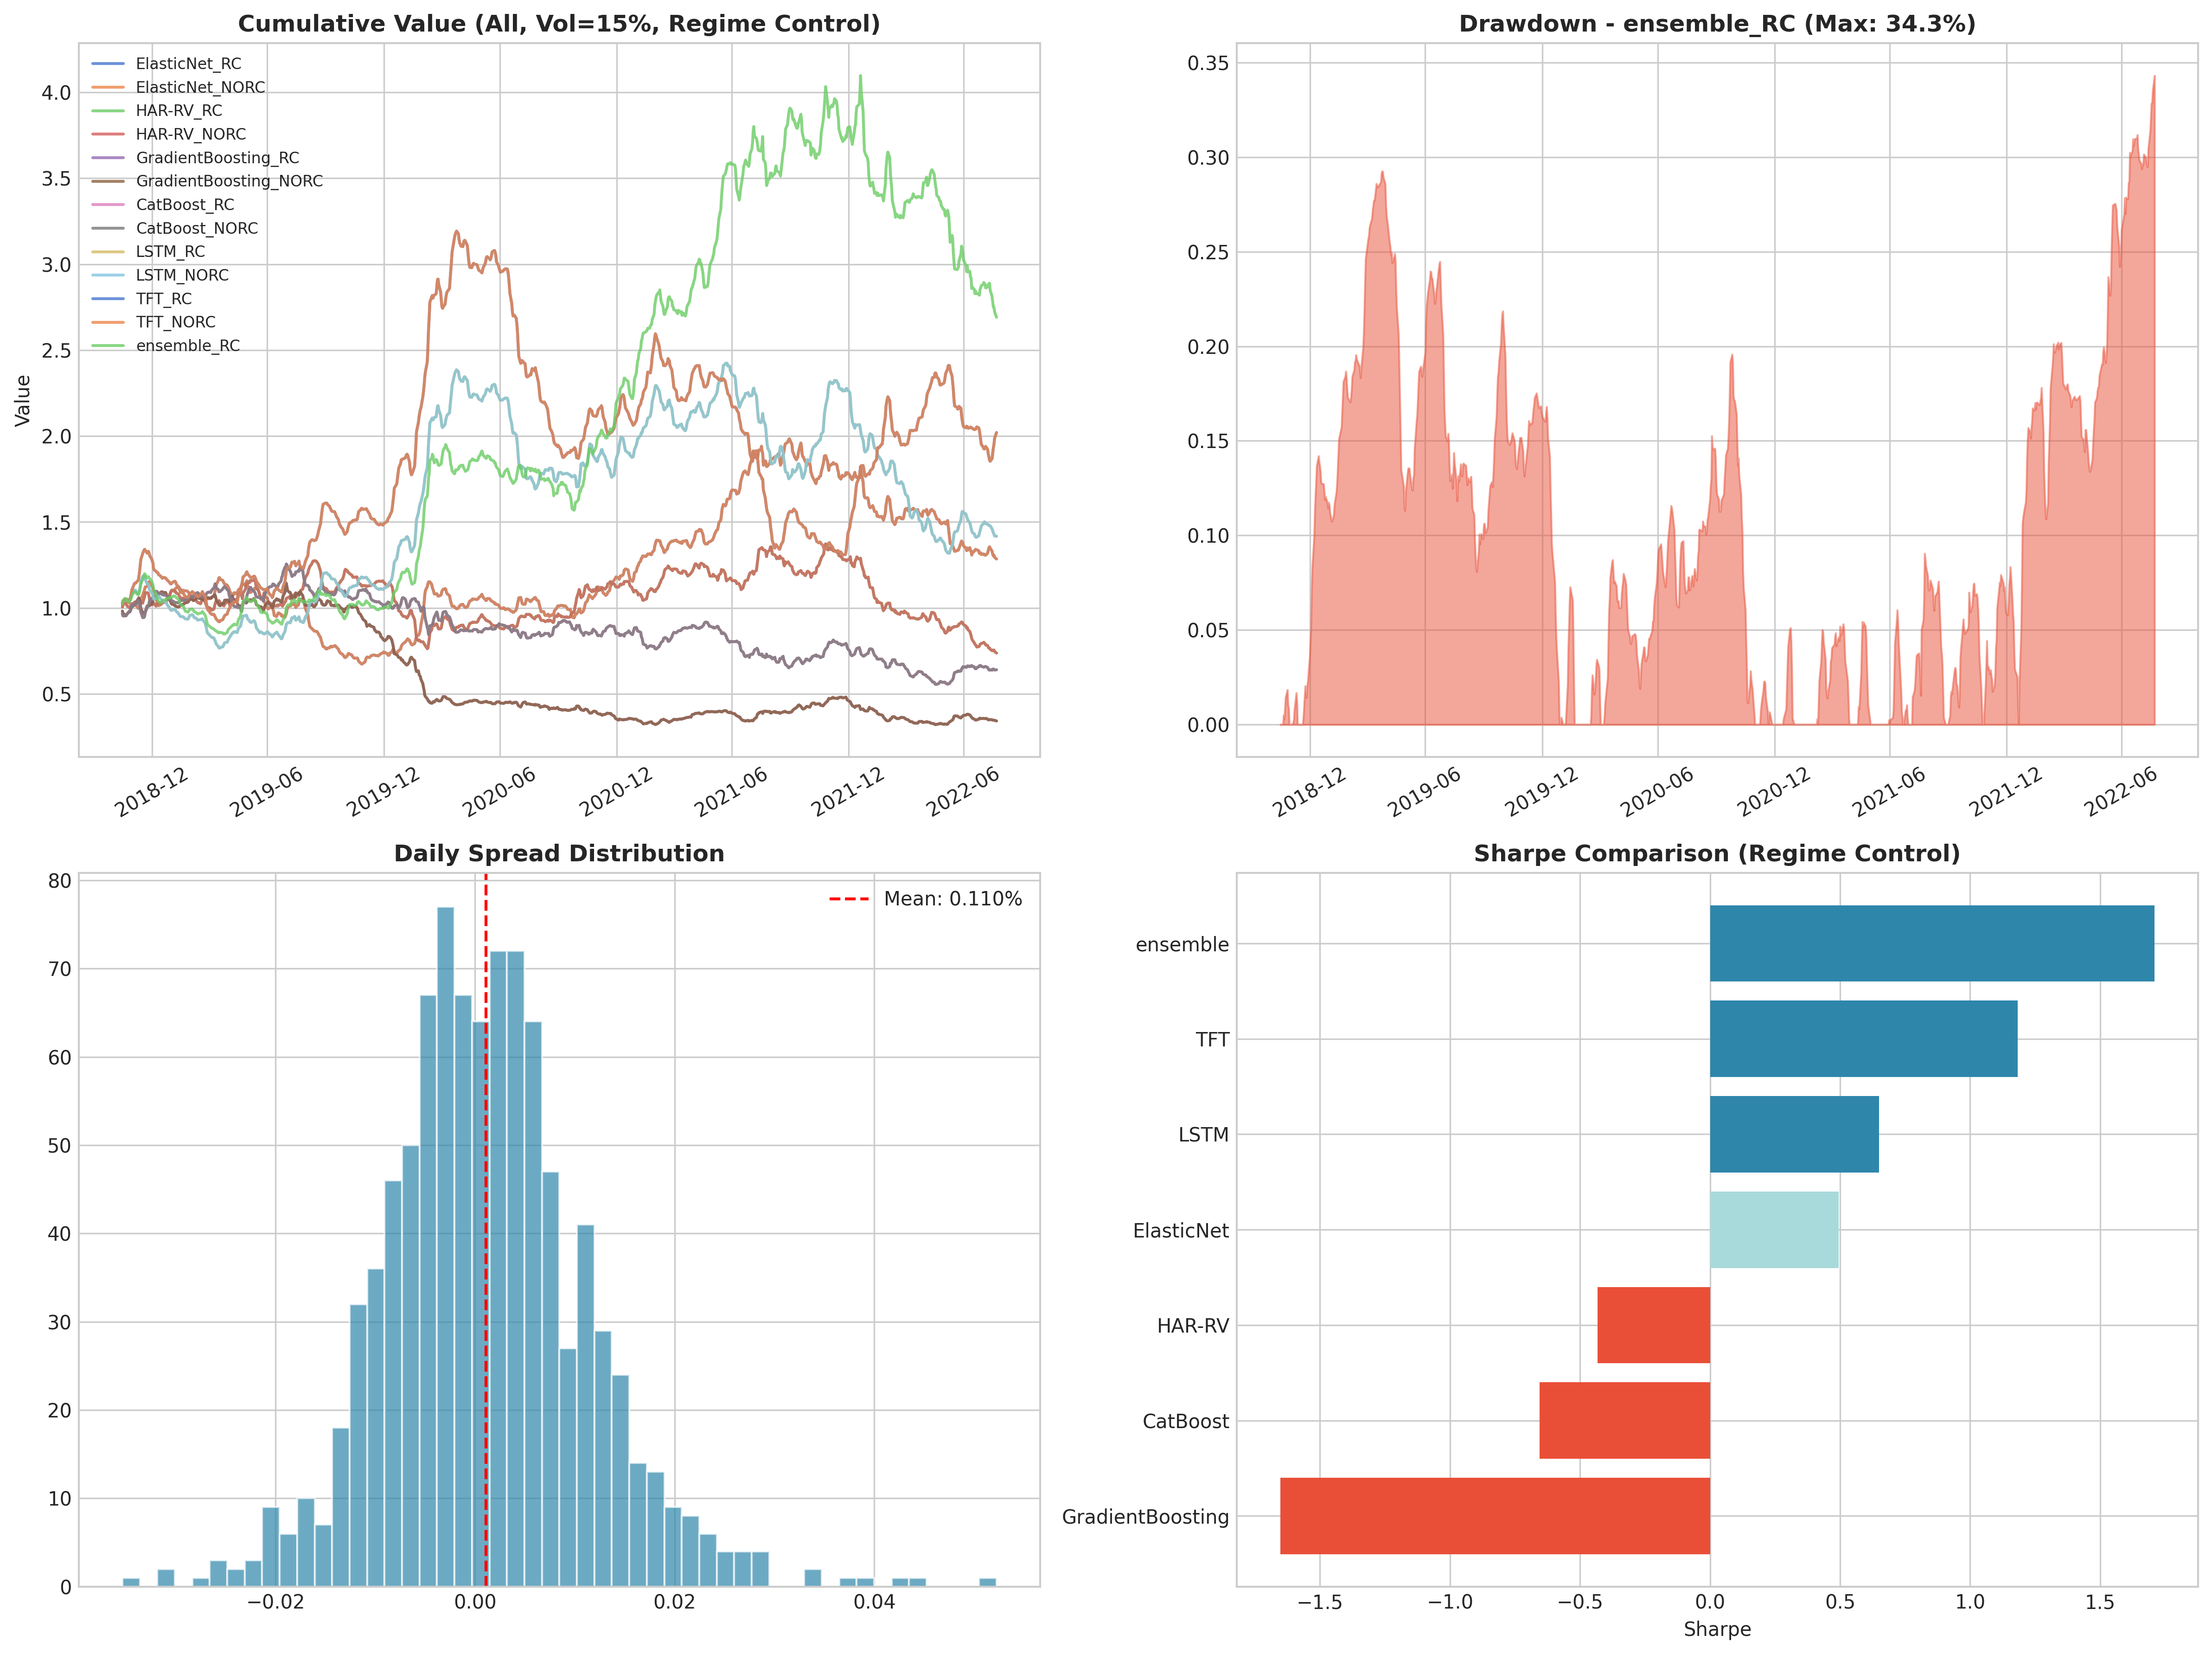

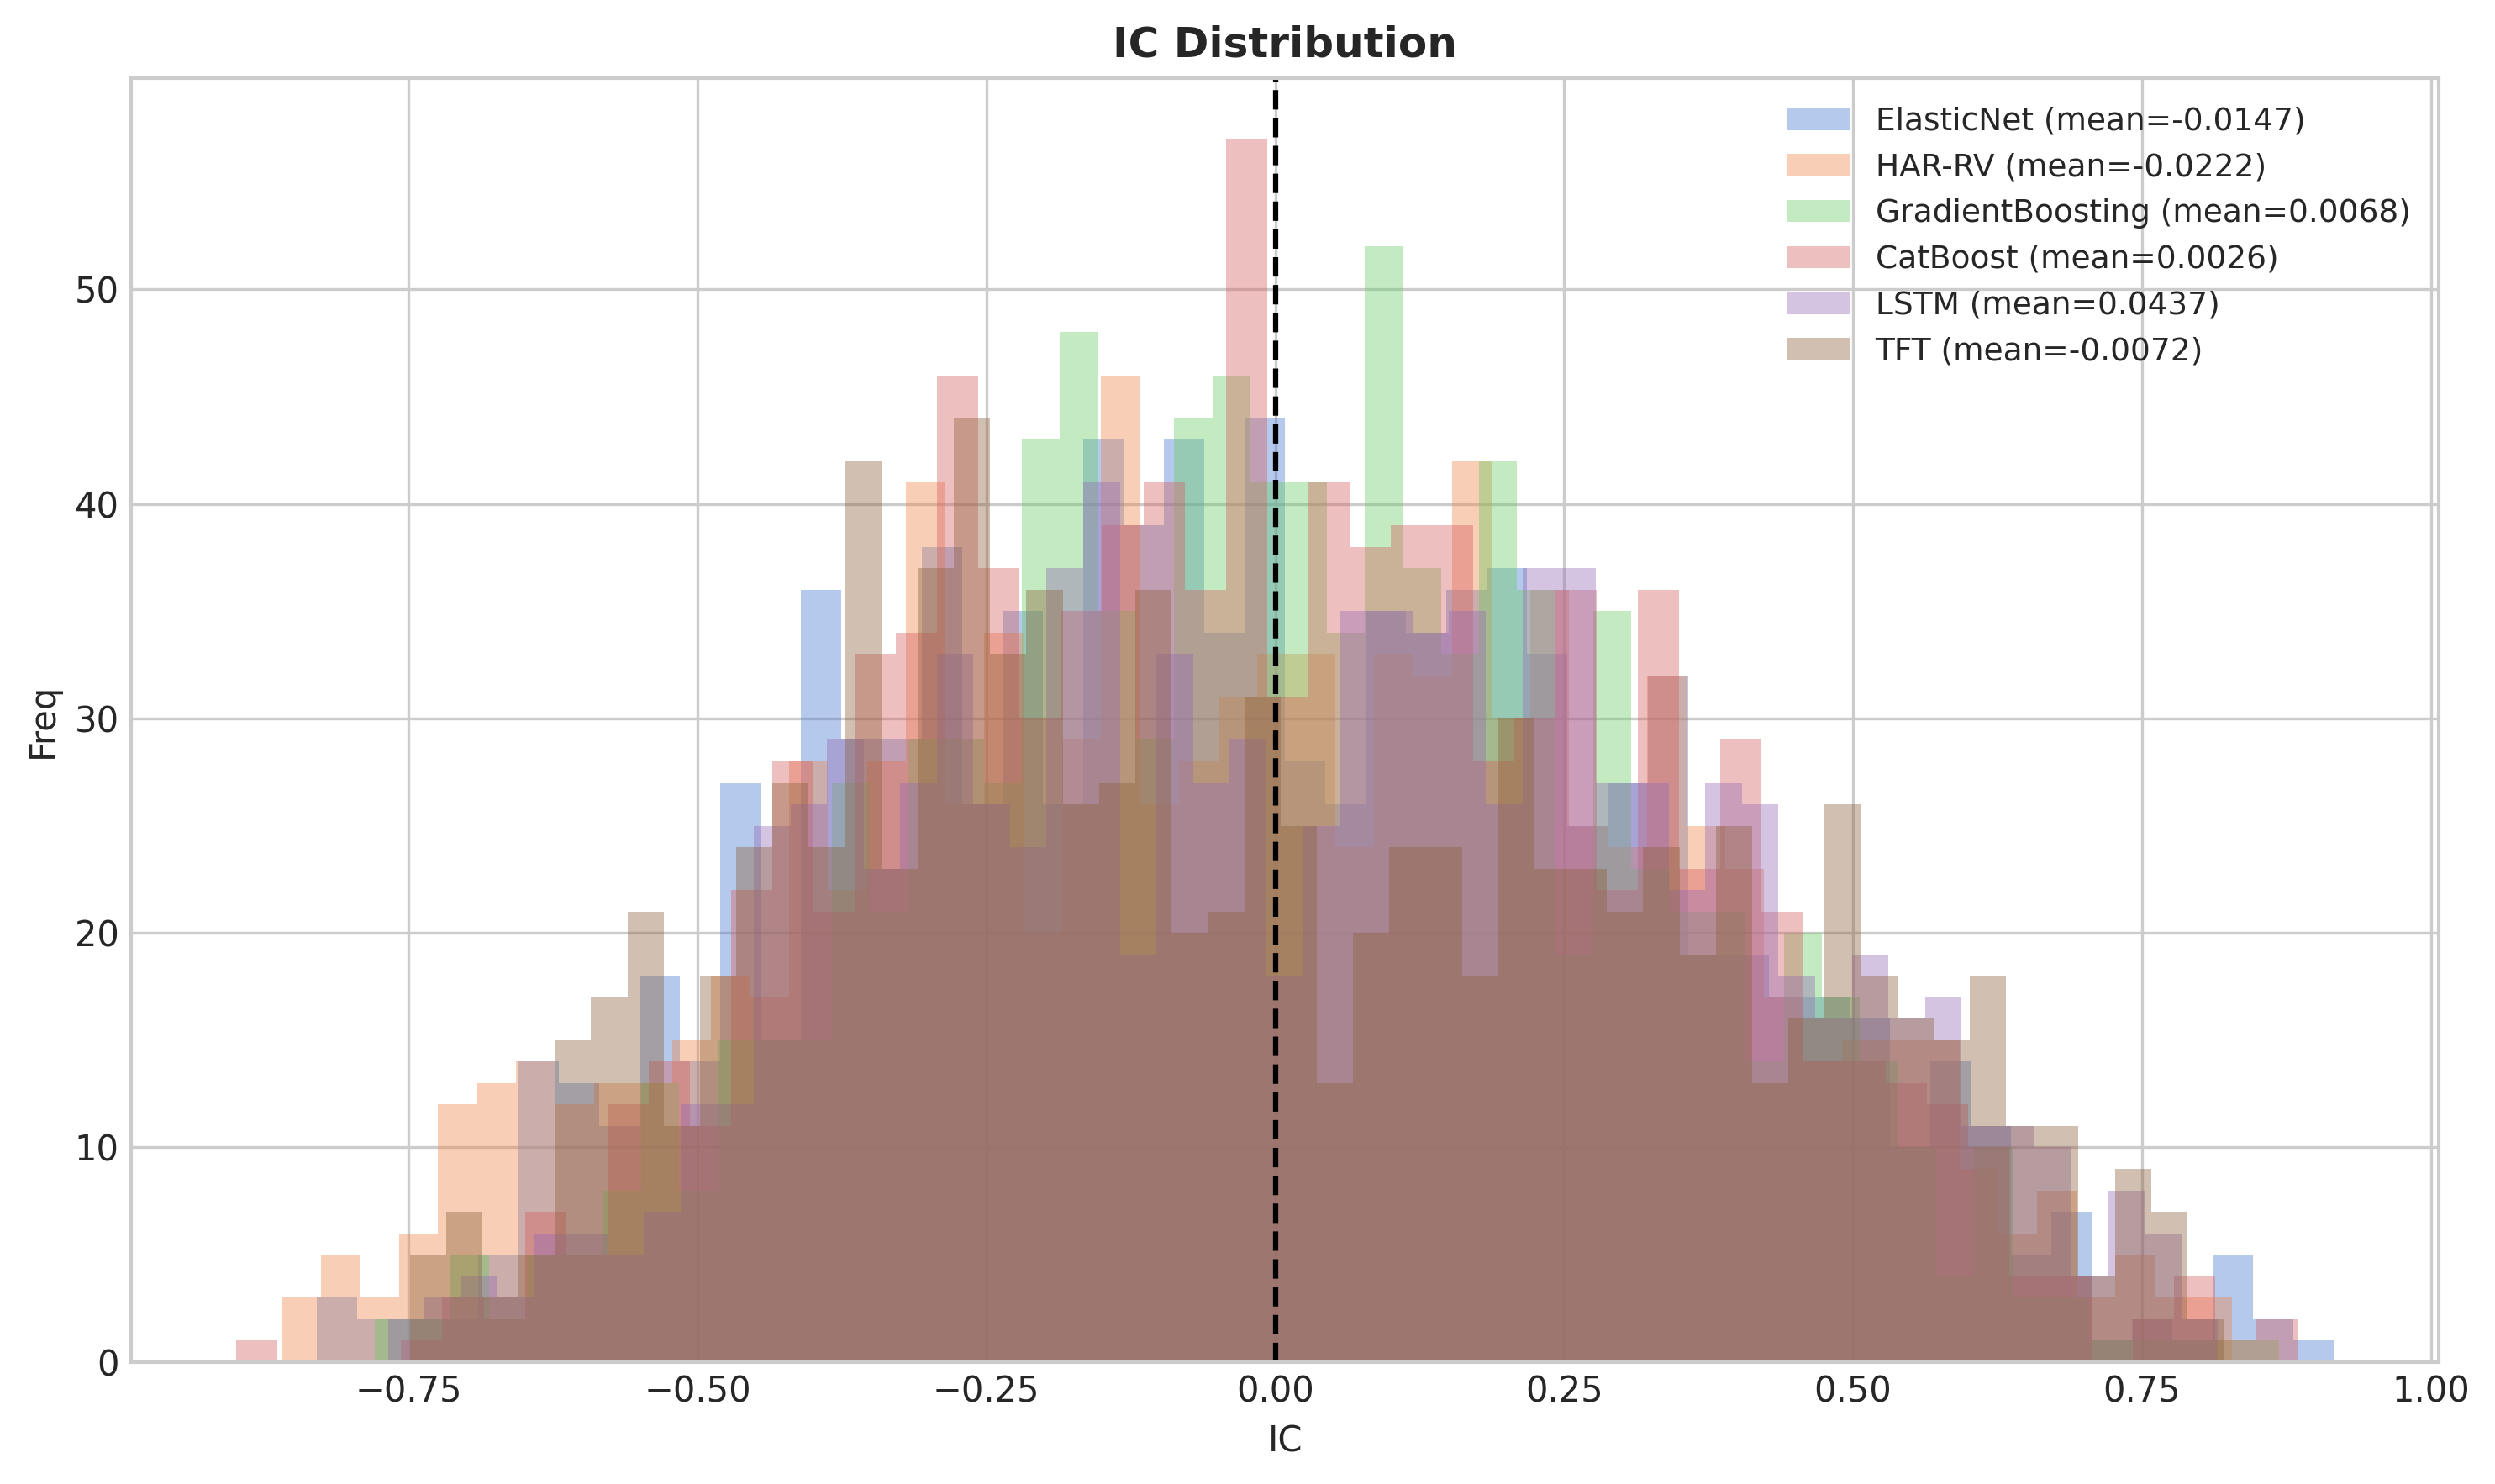

In [18]:
best_key = 'ensemble_RC' if 'ensemble_RC' in backtest_results else list(backtest_results.keys())[0]
bt_main = backtest_results[best_key]

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
# All models
ax1 = axes[0, 0]
for name, bt in backtest_results.items():
    if len(bt) > 0: ax1.plot(bt['date'], bt['cum_value_scaled'], label=name, alpha=0.8)
ax1.set_title('Cumulative Value (All, Vol=15%, Regime Control)', fontweight='bold')
ax1.set_ylabel('Value'); ax1.legend(fontsize=8); ax1.tick_params(axis='x', rotation=30)
# Drawdown
cummax = bt_main['cum_value_scaled'].cummax()
dd = (cummax - bt_main['cum_value_scaled']) / cummax
ax2 = axes[0, 1]
ax2.fill_between(bt_main['date'], 0, dd, alpha=0.5, color='#E94F37')
ax2.set_title(f'Drawdown - {best_key} (Max: {dd.max():.1%})', fontweight='bold')
ax2.tick_params(axis='x', rotation=30)
# Spread dist
ax3 = axes[1, 0]
ax3.hist(bt_main['spread_scaled'], bins=50, alpha=0.7, color='#2E86AB', edgecolor='white')
ax3.axvline(bt_main['spread_scaled'].mean(), color='red', linestyle='--',
           label=f'Mean: {bt_main["spread_scaled"].mean():.3%}')
ax3.set_title('Daily Spread Distribution', fontweight='bold'); ax3.legend()
# Sharpe comparison
ax4 = axes[1, 1]
plot_models = perf_df[perf_df['regime_control'] == True].sort_values('sharpe', ascending=True)
colors = ['#2E86AB' if s > 0.5 else '#A8DADC' if s > 0 else '#E94F37' for s in plot_models['sharpe']]
ax4.barh(plot_models['model'], plot_models['sharpe'], color=colors)
ax4.set_title('Sharpe Comparison (Regime Control)', fontweight='bold'); ax4.set_xlabel('Sharpe')
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'strategy_analysis.png'), dpi=300, bbox_inches='tight'); plt.show()

# IC
fig, ax = plt.subplots(figsize=(10, 6))
for m in MODEL_COLS:
    mic = ic_df[ic_df['model'] == m]['ic']
    if len(mic) > 0: ax.hist(mic, bins=50, alpha=0.4, label=f'{m} (mean={mic.mean():.4f})')
ax.axvline(0, color='black', linestyle='--'); ax.set_title('IC Distribution', fontweight='bold')
ax.set_xlabel('IC'); ax.set_ylabel('Freq'); ax.legend(fontsize=9)
plt.tight_layout(); plt.savefig(os.path.join(PLOTS_DIR, 'ic_distribution.png'), dpi=300, bbox_inches='tight'); plt.show()


## Section 18: Save Ensemble Config (v4)


In [19]:
# v4: Save complete ensemble configuration
ensemble_config = {
    'models': ens_models,
    'weights': {m: round(float(w), 4) for m, w in ens_weights.items()},
    'invert': {m: bool(SIGNAL_DIRECTION.get(m, False)) for m in ens_models},
    'regime_control': True,
    'regime_2_scale': 0.3,
    'vol_target': 0.15,
    'cost': 0.0005,
    'n_deciles': 10,
    'description': 'Sharpe-weighted ensemble with regime risk control'
}

with open(os.path.join(MODELS_DIR, 'ensemble_config.json'), 'w') as f:
    json.dump(ensemble_config, f, indent=2)
print(f'Saved: {os.path.join(MODELS_DIR, "ensemble_config.json")}')
print(json.dumps(ensemble_config, indent=2))

# Also save direction map
with open(os.path.join(MODELS_DIR, 'signal_direction.json'), 'w') as f:
    json.dump({m: bool(v) for m, v in SIGNAL_DIRECTION.items()}, f, indent=2)


Saved: output/models/ensemble_config.json
{
  "models": [
    "TFT",
    "LSTM",
    "ElasticNet",
    "HAR-RV"
  ],
  "weights": {
    "TFT": 0.417,
    "LSTM": 0.2445,
    "ElasticNet": 0.2094,
    "HAR-RV": 0.129
  },
  "invert": {
    "TFT": false,
    "LSTM": false,
    "ElasticNet": true,
    "HAR-RV": true
  },
  "regime_control": true,
  "regime_2_scale": 0.3,
  "vol_target": 0.15,
  "cost": 0.0005,
  "n_deciles": 10,
  "description": "Sharpe-weighted ensemble with regime risk control"
}


## Section 19: Save All Output


In [20]:
# Backtest CSV
output_csv = bt_main[['date', 'spread', 'spread_scaled', 'cum_value_scaled']].copy()
output_csv.columns = ['Date', 'Daily_Spread', 'Daily_Spread_VolScaled', 'Cumulative_Value']
output_csv.to_csv(os.path.join(OUTPUT_DIR, 'etf_strategy_backtest.csv'), index=False)
# Predictions
pred_cols = ['date', 'ticker', 'realized'] + MODEL_COLS + ['ensemble', 'regime']
pred_csv = results_ensemble[pred_cols].copy()
pred_csv.columns = ['Date', 'Ticker', 'Realized_Return_5d'] + MODEL_COLS + ['Ensemble', 'Regime']
pred_csv.to_csv(os.path.join(OUTPUT_DIR, 'etf_predictions.csv'), index=False)
# Performance
perf_df.to_csv(os.path.join(RESULTS_DIR, 'final_performance.csv'), index=False)
ic_summary.to_csv(os.path.join(RESULTS_DIR, 'model_comparison.csv'), index=False)

print('Saved:')
print(f'  {OUTPUT_DIR}/etf_strategy_backtest.csv')
print(f'  {OUTPUT_DIR}/etf_predictions.csv')
print(f'  {RESULTS_DIR}/final_performance.csv')
print(f'  {RESULTS_DIR}/model_comparison.csv')
print(f'  {MODELS_DIR}/ensemble_config.json')
print(f'  {MODELS_DIR}/signal_direction.json')
print(f'  {PLOTS_DIR}/strategy_analysis.png')
print(f'  {PLOTS_DIR}/ic_distribution.png')


Saved:
  output/etf_strategy_backtest.csv
  output/etf_predictions.csv
  output/results/final_performance.csv
  output/results/model_comparison.csv
  output/models/ensemble_config.json
  output/models/signal_direction.json
  output/plots/strategy_analysis.png
  output/plots/ic_distribution.png


## Section 20: Final Summary


In [21]:
print('=' * 60)
print('ETF CROSS-SECTIONAL STRATEGY v4 - FINAL SUMMARY')
print('=' * 60)

best_row = perf_df.loc[perf_df['sharpe'].idxmax()]
print(f'\nBest: {best_row["model"]} (regime_control={best_row["regime_control"]})')
print(f'  Sharpe: {best_row["sharpe"]:.3f} | AnnRet: {best_row["ann_ret"]:.2%} | MaxDD: {best_row["max_dd"]:.1%}')

print(f'\nAll Models (Regime Control):')
rc = perf_df[perf_df['regime_control'] == True][['model','sharpe','ann_ret','ann_vol','max_dd','calmar']].round(4)
print(rc.to_string())

if oos_perf is not None and len(oos_perf) > 0:
    print(f'\nOOS Validation:')
    print(oos_perf[['model','sharpe','ann_ret','max_dd']].round(4).to_string())

print(f'\nSignal Directions:')
for m, inv in SIGNAL_DIRECTION.items():
    print(f'  {m}: {"INVERT" if inv else "NORMAL"}')


ETF CROSS-SECTIONAL STRATEGY v4 - FINAL SUMMARY

Best: ensemble (regime_control=True)
  Sharpe: 1.709 | AnnRet: 27.69% | MaxDD: 34.3%

All Models (Regime Control):
               model  sharpe  ann_ret  ann_vol  max_dd  calmar
0         ElasticNet  0.4944   0.0799   0.1615  0.4272  0.1869
2             HAR-RV -0.4324  -0.0685   0.1584  0.4627 -0.1480
4   GradientBoosting -1.6521  -0.2714   0.1643  0.7186 -0.3777
6           CatBoost -0.6563  -0.1057   0.1611  0.5575 -0.1896
8               LSTM  0.6494   0.1062   0.1636  0.4562  0.2328
10               TFT  1.1832   0.2019   0.1707  0.5898  0.3424
12          ensemble  1.7092   0.2769   0.1620  0.3431  0.8070

OOS Validation:
              model  sharpe  ann_ret  max_dd
0        ElasticNet -2.1175  -0.3260  0.3673
1            HAR-RV -2.3918  -0.3731  0.3668
2  GradientBoosting  0.1042   0.0161  0.1868
3          CatBoost -0.5000  -0.0773  0.2669

Signal Directions:
  ElasticNet: INVERT
  HAR-RV: INVERT
  GradientBoosting: NORMAL
  Cat